In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, SimpleRNN, Dropout, Dense,GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split


df = pd.read_csv("FourRegionData.csv")
df.head(10)

,Region,Year,Month,SoilTemperature-10,SoilTemperature-30,SoilTemperature-50,Rainfall,Temperature,Min Temperature,Max Temperature,Humidity,Sunshine,Wind Speed,Surface Pressure,Solar Radiation
0,2,2001,1,17.40,18.81,19.43,0,18.38,13.04,25.44,62.68,7.94,2.17,101268.29,199.25
1,2,2001,2,19.88,19.98,20.36,1,22.61,16.90,28.56,61.71,7.19,1.98,101039.08,210.73
2,2,2001,3,24.08,23.32,23.17,33,26.62,20.73,31.84,55.48,8.75,2.10,100882.56,251.75
3,2,2001,4,27.62,27.02,26.77,46,29.06,24.71,32.06,65.63,8.55,2.70,100655.40,257.46
4,2,2001,5,28.54,28.29,28.21,402,27.69,24.18,32.09,77.39,6.10,2.37,100234.63,172.32
5,2,2001,6,30.11,29.82,29.64,386,28.03,25.55,31.75,83.17,3.51,3.64,99934.18,140.45
6,2,2001,7,30.74,30.53,30.64,202,28.83,25.92,31.60,80.26,4.55,3.87,99991.05,169.40
7,2,2001,8,30.99,30.99,30.86,205,29.46,25.23,31.50,82.19,5.15,3.01,100129.68,181.66
8,2,2001,9,29.83,29.89,29.95,209,28.71,24.34,32.42,82.53,4.65,2.14,100499.17,170.22
9,2,2001,10,28.00,28.29,28.50,177,27.63,22.83,31.44,80.45,5.60,1.59,100864.38,167.89


In [3]:
features = df[['Month', 'Temperature', 'Min Temperature',
               'Max Temperature', 
               'Rainfall', 'Surface Pressure']]
target = df['SoilTemperature-50']

In [4]:

# Feature scaling with StandardScaler
feat_scaler = StandardScaler()
X_scaled = feat_scaler.fit_transform(features)

# Target scaling with MinMaxScaler
tgt_scaler = MinMaxScaler()
y_scaled = tgt_scaler.fit_transform(target.values.reshape(-1, 1))
# === 4. Sliding-window sequencing ============================================
def create_sliding_window(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

WINDOW = 12  # Define the window size for time-series sequences
X_seq, y_seq = create_sliding_window(X_scaled, y_scaled, WINDOW)

X_train, X_tmp, y_train, y_tmp = train_test_split(X_seq, y_seq,
                                                  test_size=0.2,
                                                  random_state=2)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp,
                                                test_size=0.5,
                                                random_state=2)


cnn_lstm_model = Sequential([
    # Conv1D Layer for feature extraction
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    # LSTM Layers
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    # Fully connected layers
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)  # Output layer
])

cnn_lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# 2. SimpleRNN Model Definition
simple_rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    SimpleRNN(32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)  
])

simple_rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# 3. LSTM Model Definition
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)  # Output layer
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# 4. GRU Model Definition
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)  # Output layer
])

gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# === 5. Callbacks ============================================================
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, mode='min')
lr_sched = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

cnn_lstm_history = cnn_lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint, lr_sched],
    verbose=1
)

cnn_lstm_loss, cnn_lstm_mae = cnn_lstm_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss (MSE): {cnn_lstm_loss:.4f}")
print(f"Test MAE:       {cnn_lstm_mae:.4f}")

# Train SimpleRNN
simple_rnn_history = simple_rnn_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint, lr_sched],
    verbose=1
)
simple_rnn_loss, simple_rnn_mae = simple_rnn_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss (MSE): {simple_rnn_loss:.4f}")
print(f"Test MAE:       {simple_rnn_mae:.4f}")

# Train LSTM
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint, lr_sched],
    verbose=1
)
lstm_loss, lstm_mae = lstm_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss (MSE): {lstm_loss:.4f}")
print(f"Test MAE:       {lstm_mae:.4f}")

# Train GRU
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint, lr_sched],
    verbose=1
)

gru_loss, gru_mae = gru_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss (MSE): {gru_loss:.4f}")
print(f"Test MAE:       {gru_mae:.4f}")

models = ['CNN-LSTM', 'SimpleRNN', 'LSTM', 'GRU']
test_losses = [cnn_lstm_loss, simple_rnn_loss, lstm_loss, gru_loss]






Epoch 1/100


27/27 [==============================] - 6s 53ms/step - loss: 0.1371 - mae: 0.2961 - val_loss: 0.0509 - val_mae: 0.2023 - lr: 0.0010
Epoch 2/100
13/27 [=============>................] - ETA: 0s - loss: 0.0552 - mae: 0.1958

C:\Users\HP Laptop 15\tfenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


27/27 [==============================] - 0s 14ms/step - loss: 0.0455 - mae: 0.1741 - val_loss: 0.0150 - val_mae: 0.0942 - lr: 0.0010
Epoch 3/100
27/27 [==============================] - 0s 13ms/step - loss: 0.0231 - mae: 0.1186 - val_loss: 0.0120 - val_mae: 0.0859 - lr: 0.0010
Epoch 4/100
27/27 [==============================] - 0s 14ms/step - loss: 0.0197 - mae: 0.1097 - val_loss: 0.0102 - val_mae: 0.0771 - lr: 0.0010
Epoch 5/100
27/27 [==============================] - 0s 12ms/step - loss: 0.0193 - mae: 0.1061 - val_loss: 0.0140 - val_mae: 0.0974 - lr: 0.0010
Epoch 6/100
27/27 [==============================] - 0s 13ms/step - loss: 0.0177 - mae: 0.1030 - val_loss: 0.0096 - val_mae: 0.0730 - lr: 0.0010
Epoch 7/100
27/27 [==============================] - 0s 12ms/step - loss: 0.0189 - mae: 0.1043 - val_loss: 0.0114 - val_mae: 0.0860 - lr: 0.0010
Epoch 8/100
27/27 [==============================] - 0s 13ms/step - loss: 0.0140 - mae: 0.0911 - val_loss: 0.0083 - val_mae: 0.0695 - lr: 0.00

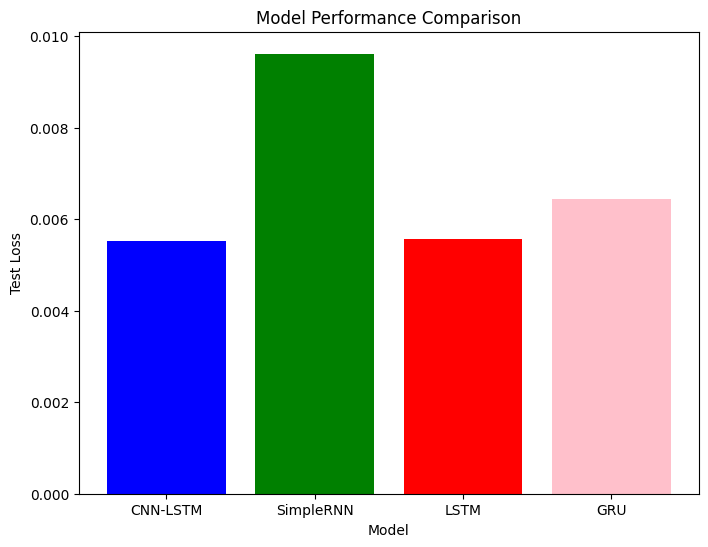

In [5]:
# Plotting
plt.figure(figsize=(8, 6))
plt.bar(models, test_losses, color=['blue', 'green', 'red','pink'])
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Test Loss')
plt.show()

In [6]:
print(test_losses)

[0.005517661105841398, 0.009613730013370514, 0.005556092597544193, 0.006433664821088314]


Epoch 1/100
23/23 [==============================] - 5s 53ms/step - loss: 0.1279 - mae: 0.2859 - val_loss: 0.0545 - val_mae: 0.2103 - lr: 0.0010
Epoch 2/100
 8/23 [=========>....................] - ETA: 0s - loss: 0.0667 - mae: 0.2225

C:\Users\HP Laptop 15\tfenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


23/23 [==============================] - 0s 15ms/step - loss: 0.0556 - mae: 0.1946 - val_loss: 0.0237 - val_mae: 0.1232 - lr: 0.0010
Epoch 3/100
23/23 [==============================] - 0s 15ms/step - loss: 0.0293 - mae: 0.1347 - val_loss: 0.0142 - val_mae: 0.0887 - lr: 0.0010
Epoch 4/100
23/23 [==============================] - 0s 16ms/step - loss: 0.0228 - mae: 0.1162 - val_loss: 0.0085 - val_mae: 0.0703 - lr: 0.0010
Epoch 5/100
23/23 [==============================] - 0s 12ms/step - loss: 0.0188 - mae: 0.1056 - val_loss: 0.0099 - val_mae: 0.0738 - lr: 0.0010
Epoch 6/100
23/23 [==============================] - 0s 17ms/step - loss: 0.0196 - mae: 0.1060 - val_loss: 0.0084 - val_mae: 0.0682 - lr: 0.0010
Epoch 7/100
23/23 [==============================] - 0s 12ms/step - loss: 0.0164 - mae: 0.0981 - val_loss: 0.0093 - val_mae: 0.0718 - lr: 0.0010
Epoch 8/100
23/23 [==============================] - 0s 12ms/step - loss: 0.0154 - mae: 0.0946 - val_loss: 0.0085 - val_mae: 0.0670 - lr: 0.00

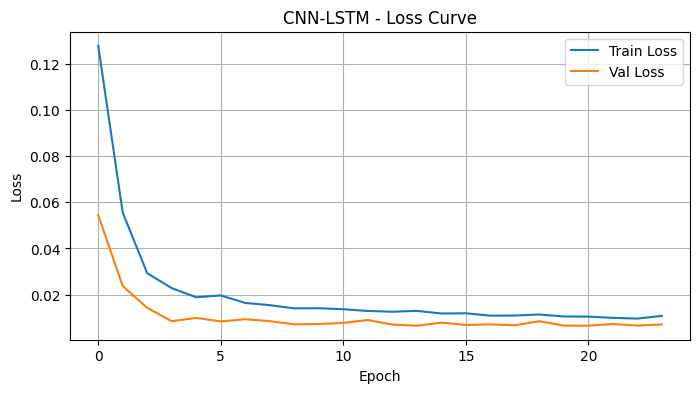

Epoch 1/100
23/23 [==============================] - 3s 65ms/step - loss: 0.1694 - mae: 0.3312 - val_loss: 0.0209 - val_mae: 0.1102 - lr: 0.0010
Epoch 2/100
23/23 [==============================] - 0s 11ms/step - loss: 0.1167 - mae: 0.2719 - val_loss: 0.0191 - val_mae: 0.1059 - lr: 0.0010
Epoch 3/100
23/23 [==============================] - 0s 10ms/step - loss: 0.0873 - mae: 0.2338 - val_loss: 0.0137 - val_mae: 0.0906 - lr: 0.0010
Epoch 4/100
23/23 [==============================] - 0s 8ms/step - loss: 0.0720 - mae: 0.2135 - val_loss: 0.0167 - val_mae: 0.1031 - lr: 0.0010
Epoch 5/100
23/23 [==============================] - 0s 12ms/step - loss: 0.0615 - mae: 0.1982 - val_loss: 0.0126 - val_mae: 0.0867 - lr: 0.0010
Epoch 6/100
23/23 [==============================] - 0s 8ms/step - loss: 0.0521 - mae: 0.1800 - val_loss: 0.0191 - val_mae: 0.1147 - lr: 0.0010
Epoch 7/100
23/23 [==============================] - 0s 9ms/step - loss: 0.0461 - mae: 0.1684 - val_loss: 0.0236 - val_mae: 0.1290 -

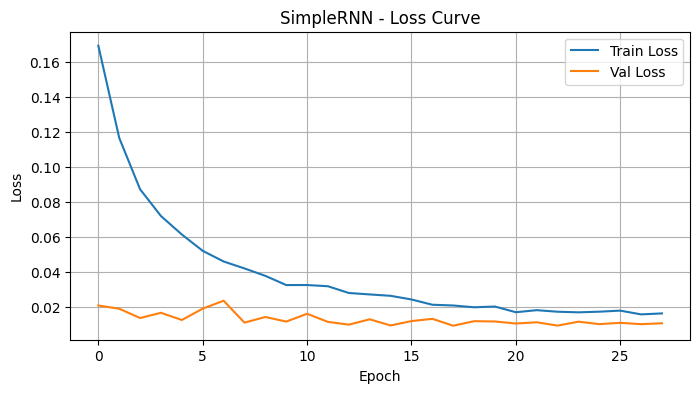

Epoch 1/100
23/23 [==============================] - 5s 53ms/step - loss: 0.1688 - mae: 0.3360 - val_loss: 0.0395 - val_mae: 0.1686 - lr: 0.0010
Epoch 2/100
23/23 [==============================] - 0s 17ms/step - loss: 0.0305 - mae: 0.1372 - val_loss: 0.0144 - val_mae: 0.0901 - lr: 0.0010
Epoch 3/100
23/23 [==============================] - 0s 18ms/step - loss: 0.0231 - mae: 0.1154 - val_loss: 0.0072 - val_mae: 0.0661 - lr: 0.0010
Epoch 4/100
23/23 [==============================] - 0s 18ms/step - loss: 0.0198 - mae: 0.1069 - val_loss: 0.0069 - val_mae: 0.0643 - lr: 0.0010
Epoch 5/100
23/23 [==============================] - 0s 15ms/step - loss: 0.0190 - mae: 0.1056 - val_loss: 0.0111 - val_mae: 0.0786 - lr: 0.0010
Epoch 6/100
23/23 [==============================] - 0s 18ms/step - loss: 0.0172 - mae: 0.1001 - val_loss: 0.0066 - val_mae: 0.0620 - lr: 0.0010
Epoch 7/100
23/23 [==============================] - 0s 18ms/step - loss: 0.0153 - mae: 0.0949 - val_loss: 0.0063 - val_mae: 0.060

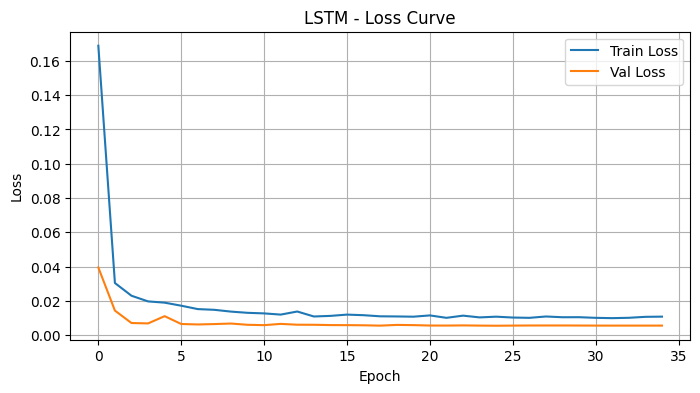

Epoch 1/100
23/23 [==============================] - 5s 53ms/step - loss: 0.0901 - mae: 0.2309 - val_loss: 0.0070 - val_mae: 0.0667 - lr: 0.0010
Epoch 2/100
23/23 [==============================] - 0s 17ms/step - loss: 0.0257 - mae: 0.1235 - val_loss: 0.0056 - val_mae: 0.0570 - lr: 0.0010
Epoch 3/100
23/23 [==============================] - 0s 15ms/step - loss: 0.0225 - mae: 0.1173 - val_loss: 0.0052 - val_mae: 0.0560 - lr: 0.0010
Epoch 4/100
23/23 [==============================] - 0s 17ms/step - loss: 0.0192 - mae: 0.1065 - val_loss: 0.0051 - val_mae: 0.0542 - lr: 0.0010
Epoch 5/100
23/23 [==============================] - 0s 14ms/step - loss: 0.0178 - mae: 0.1041 - val_loss: 0.0052 - val_mae: 0.0550 - lr: 0.0010
Epoch 6/100
23/23 [==============================] - 0s 14ms/step - loss: 0.0171 - mae: 0.1010 - val_loss: 0.0058 - val_mae: 0.0588 - lr: 0.0010
Epoch 7/100
23/23 [==============================] - 0s 17ms/step - loss: 0.0142 - mae: 0.0915 - val_loss: 0.0051 - val_mae: 0.053

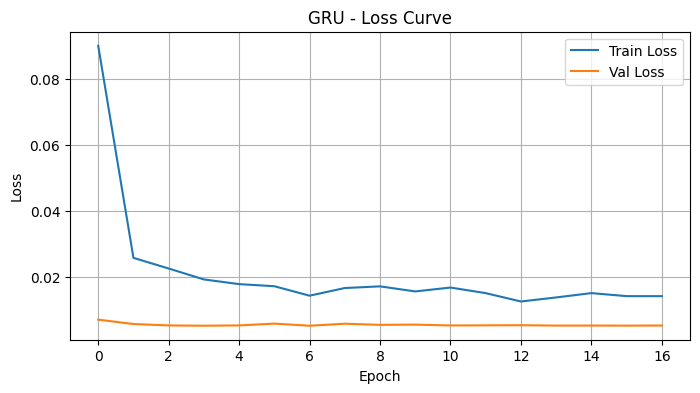


Final Results:
CNN-LSTM: MSE = 0.0096, MAE = 0.0830
SimpleRNN: MSE = 0.0050, MAE = 0.0559
LSTM: MSE = 0.0092, MAE = 0.0805
GRU: MSE = 0.0062, MAE = 0.0607


In [10]:

feat_scaler = StandardScaler()
X_scaled = feat_scaler.fit_transform(features)

tgt_scaler = MinMaxScaler()
y_scaled = tgt_scaler.fit_transform(target.values.reshape(-1, 1))

def create_sliding_window(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

WINDOW = 12
X_seq, y_seq = create_sliding_window(X_scaled, y_scaled, WINDOW)

total_samples = len(X_seq)
train_end = int(0.7 * total_samples)
val_end = int(0.85 * total_samples)

X_train, y_train = X_seq[:train_end], y_seq[:train_end]
X_val, y_val = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test, y_test = X_seq[val_end:], y_seq[val_end:]

def build_cnn_lstm_model(input_shape):
    model = Sequential([
        Conv1D(64, 3, activation='relu', padding='same', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    return model

def build_simple_rnn_model(input_shape):
    model = Sequential([
        SimpleRNN(64, activation='tanh', return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        SimpleRNN(32, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    return model

def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    return model

def build_gru_model(input_shape):
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    return model

def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_sched = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

models = {
    "CNN-LSTM": build_cnn_lstm_model(X_train.shape[1:]),
    "SimpleRNN": build_simple_rnn_model(X_train.shape[1:]),
    "LSTM": build_lstm_model(X_train.shape[1:]),
    "GRU": build_gru_model(X_train.shape[1:])
}

histories = {}
results = {}

for name, model in models.items():
    checkpoint = ModelCheckpoint(f"{name.lower()}_best.h5", monitor='val_loss', save_best_only=True, mode='min')
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val),
                        callbacks=[early_stop, checkpoint, lr_sched], verbose=1)
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name}: Test MSE = {loss:.4f}, MAE = {mae:.4f}")
    histories[name] = history
    results[name] = {'mse': loss, 'mae': mae}
    plot_history(history, name)

print("\nFinal Results:")
for name, res in results.items():
    print(f"{name}: MSE = {res['mse']:.4f}, MAE = {res['mae']:.4f}")
